# Notebook 02 — Preprocessing & Feature Extraction

Demonstrates the full text cleaning pipeline and TF-IDF feature matrix.

In [1]:
import sys; sys.path.insert(0, '..')
import pickle, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import load_npz
import joblib
from src.preprocessing import clean_text, preprocess_text, preprocess_corpus
from src.features import build_tfidf, reduce_with_svd


## 1. Preprocessing Pipeline Walk-through

In [2]:
sample = [
    'The quick Brown Foxes are RUNNING over 42 lazy dogs! Visit http://example.com for more info.',
    '<b>NASA</b> launched a new satellite into low-earth orbit on Friday.',
    'The government encryption policy involving NSA clipper chips was controversial.',
]
print('=== RAW TEXT ===')
for i, t in enumerate(sample): print(f'  [{i}] {t}')
print('\n=== AFTER clean_text() ===')
for i, t in enumerate(sample): print(f'  [{i}] {clean_text(t)}')
print('\n=== AFTER preprocess_text() (full pipeline) ===')
for i, t in enumerate(sample): print(f'  [{i}] {preprocess_text(t)}')


=== RAW TEXT ===
  [0] The quick Brown Foxes are RUNNING over 42 lazy dogs! Visit http://example.com for more info.
  [1] <b>NASA</b> launched a new satellite into low-earth orbit on Friday.
  [2] The government encryption policy involving NSA clipper chips was controversial.

=== AFTER clean_text() ===
  [0] the quick brown foxes are running over lazy dogs visit for more info
  [1] nasa launched a new satellite into low earth orbit on friday
  [2] the government encryption policy involving nsa clipper chips was controversial

=== AFTER preprocess_text() (full pipeline) ===


  [0] quick brown fox running lazy dog visit info
  [1] nasa launched new satellite low earth orbit friday
  [2] government encryption policy involving nsa clipper chip controversial


## 2. Vocabulary & Token Statistics

In [3]:
from sklearn.datasets import fetch_20newsgroups
import re, nltk
from nltk.corpus import stopwords
news = fetch_20newsgroups(subset='all', remove=('headers','footers','quotes'), random_state=42)
raw_texts = news.data[:500]
processed, kept = preprocess_corpus(raw_texts, min_doc_len=10)
print(f'Input : {len(raw_texts)} docs')
print(f'Output: {len(processed)} docs ({len(raw_texts)-len(processed)} dropped)')
STOPS = set(stopwords.words('english'))
raw_tokens  = [re.findall(r'\b[a-z]{3,}\b', t.lower()) for t in raw_texts]
proc_tokens = [t.split() for t in processed]
raw_mean  = np.mean([len(t) for t in raw_tokens])
proc_mean = np.mean([len(t) for t in proc_tokens])
print(f'\nMean tokens — raw: {raw_mean:.1f}  |  processed: {proc_mean:.1f}')
print(f'Compression: {(1 - proc_mean/raw_mean)*100:.1f}% reduction')


Input : 500 docs
Output: 482 docs (18 dropped)

Mean tokens — raw: 112.0  |  processed: 76.1
Compression: 32.0% reduction


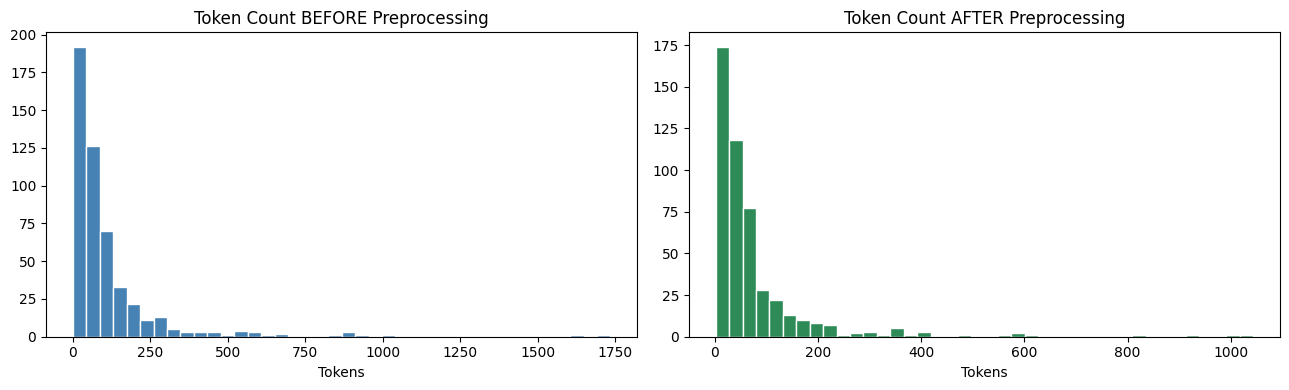

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist([len(t) for t in raw_tokens], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Token Count BEFORE Preprocessing'); axes[0].set_xlabel('Tokens')
axes[1].hist([len(t) for t in proc_tokens], bins=40, color='seagreen', edgecolor='white')
axes[1].set_title('Token Count AFTER Preprocessing'); axes[1].set_xlabel('Tokens')
plt.tight_layout(); plt.savefig('../outputs/figures/preprocessing_tokens.png', bbox_inches='tight'); plt.show()


## 3. TF-IDF Feature Matrix

In [5]:
vec_ng = joblib.load('../models/tfidf_newsgroups.pkl')
X_ng   = np.load('../models/X_reduced_newsgroups.npy')
print(f'Vocab size  : {len(vec_ng.vocabulary_):,}')
print(f'X_reduced   : {X_ng.shape}')
# Load X_tfidf from data/processed if available
try:
    X_tfidf_ng = load_npz('../data/processed/X_tfidf_newsgroups.npz')
    print(f'TF-IDF shape: {X_tfidf_ng.shape}')
    print(f'Sparsity    : {1 - X_tfidf_ng.nnz / (X_tfidf_ng.shape[0]*X_tfidf_ng.shape[1]):.3%}')
except FileNotFoundError:
    print('X_tfidf not cached locally — run the full pipeline to generate data/processed/')
    X_tfidf_ng = None


Vocab size  : 10,000
X_reduced   : (18195, 100)
TF-IDF shape: (18195, 10000)
Sparsity    : 99.430%


## 4. LSA — Explained Variance

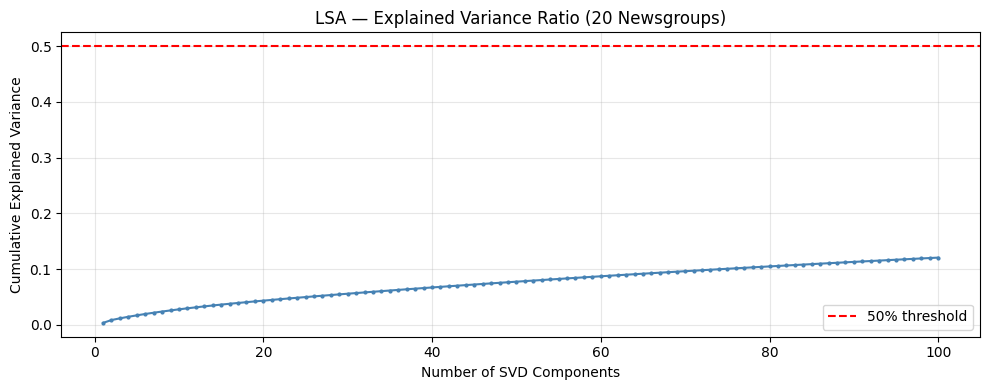

100 components explain 12.1% of variance


In [6]:
svd_ng = joblib.load('../models/svd_newsgroups.pkl')
explained = svd_ng.named_steps['svd'].explained_variance_ratio_
cumulative = np.cumsum(explained)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(cumulative)+1), cumulative, marker='.', markersize=4, color='steelblue')
ax.axhline(0.5, linestyle='--', color='red', label='50% threshold')
ax.set_xlabel('Number of SVD Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('LSA — Explained Variance Ratio (20 Newsgroups)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('../outputs/figures/svd_variance_newsgroups.png', bbox_inches='tight'); plt.show()
print(f'100 components explain {cumulative[99]:.1%} of variance')
